## Introduction

This notebook is a **bare-minimum starter model** of a 2D laboratory
groundwater tank. Its purpose is to give you a clean, working FloPy
script that you can use as a launching pad — replacing parameters,
swapping in different boundary conditions, adding reactive transport,
running sensitivity analyses, and so on.

We use **MODFLOW-2005** for steady-state flow and **MT3D-USGS** for
solute transport. The same workflow we used in the earlier 1D function
and 2D macrodispersion notebooks applies here, just with a more
realistic (irregularly shaped, heterogeneous) geometry.

### What the model represents

A vertical cross-section through a physical sand-tank apparatus,
124 cm long and 54 cm tall. The tank contains three lithologies — sand,
gravel, and clay. A constant head is held at each end of the tank to drive horizontal
flow, and a constant head "river" segment partway across the top discharges water
at a lower elevation. A network of 28 small observation wells
(named `1A`–`5D` and `W1`–`W9`) is distributed through the tank.
In lab we pick one well as an **injection point** for a tracer pulse and
watch the plume migrate.

### What you will need

Two text files in the same folder as this notebook:

- `tank_hydrostrat_coarse.txt` — a 50×120 grid of integers giving the
  lithology in each cell (`0` = out of bounds, `1` = sand, `2` = gravel,
  `3` = clay).
- `tank_heads_and_wells_coarse.txt` — a 50×120 grid of integers marking
  special cells: `1` = constant-head ("river") cells, `2` = observation
  well cells, `0` = nothing special.

Begin by importing the standard libraries.


In [1]:
# Import the FloPy library
import flopy

# Standard library
import os
import time

# Numerical / plotting
import numpy as np
import matplotlib.pyplot as plt

print("FloPy version:", flopy.__version__)


FloPy version: 3.9.2


## Executable paths

Locate the MODFLOW-2005 and MT3D-USGS executables on your system and
update the paths below. We use `os.path.exists` to verify that the
executables actually live where we say they do — this catches the most
common configuration error before the model fails further down.


In [3]:
# Path to the MODFLOW-2005 executable (often named mf2005 or mf2005.exe)
exe_name_mf = 'C:\\Hydro\\mf2005.exe'
# Path to the MT3D-USGS executable
exe_name_mt = 'C:\\Hydro\\mt3dusgs.exe'

# Verify that the executables exist at the paths above. If either prints
# False, fix the path before continuing — the model will fail to run.
print("MODFLOW executable path exists:", os.path.exists(exe_name_mf))
print("MT3D executable path exists:", os.path.exists(exe_name_mt))


MODFLOW executable path exists: True
MT3D executable path exists: True


## Working directory

The cell below prints your current working directory — this is where
relative paths are resolved (including the location of the two tank
data files). It should be wherever you have this notebook saved.


In [4]:
# Print the current working directory
current_directory = os.getcwd()
print("Current working directory:", current_directory)


Current working directory: C:\Users\czahasky\Downloads


Now create a sub-directory called `tank_models` to hold all the model
input and output files. Each model run will create its own folder
inside this directory, named with the `dirname` argument.


In [5]:
# Sub-directory (relative to the current working directory) where each
# call to the model function will create its own folder
directory_name = 'tank_models'
workdir = os.path.join('.', directory_name)

# Create the directory if it does not already exist
if not os.path.isdir(workdir):
    os.mkdir(workdir)
    print("Directory '%s' created" % workdir)
else:
    print("Directory '%s' already exists" % workdir)


Directory '.\tank_models' created


## Plotting helper

`plot_2d` is a small wrapper around `matplotlib.pyplot.pcolormesh` that
we use repeatedly to plot 2D fields (lithology, conductivity, heads,
concentration, etc.). It builds the cell-edge coordinates from the
cell sizes you pass in and adds a colorbar with an optional label.


In [6]:
def plot_2d(map_data, dx, dy, colorbar_label='', cmap='cividis',
            title='', clim=None, dpi=150):
    """
    Plot a 2D field as a pcolormesh.

    Parameters
    ----------
    map_data : ndarray, shape (rows, cols)
        Data to plot. Use np.squeeze(...) on a 3D MODFLOW array to
        drop the row dimension first.
    dx, dy : float
        Cell size in the x and y directions (cm).
    colorbar_label : str
        Label for the colorbar.
    cmap : str
        Matplotlib colormap name.
    title : str
        Plot title.
    clim : tuple of (vmin, vmax) or None
        Color-axis limits. None lets matplotlib choose.
    dpi : int
        Figure resolution.
    """
    rows, cols = map_data.shape
    x_coord = np.linspace(0, dx * cols, cols + 1)
    y_coord = np.linspace(0, dy * rows, rows + 1)
    X, Y = np.meshgrid(x_coord, y_coord)

    plt.figure(figsize=(9, 2.2), dpi=dpi)
    plt.pcolormesh(X, Y, map_data, cmap=cmap, shading='flat')
    plt.gca().set_aspect('equal')
    cbar = plt.colorbar()
    cbar.set_label(colorbar_label)
    if clim is not None:
        plt.clim(clim)
    plt.xlabel('Distance [cm]')
    plt.ylabel('Depth [cm]')
    plt.xlim(0, dx * cols)
    plt.ylim(0, dy * rows)
    plt.title(title)
    plt.show()


## Load the tank geometry

Both data files are 50×120 grids — 50 rows (vertical, top to bottom)
and 120 columns (horizontal, left to right). To turn this 2D map into
a MODFLOW grid, we treat the **vertical dimension as model layers** and
the **horizontal dimension as model columns**, with `nrow = 1` (a 1-cell-
thick cross-section).

We also set the physical cell sizes:
- `delc` = horizontal cell width (cm) — derived from total tank length / ncol
- `delv` = layer thickness (cm) — derived from total tank height / nlay
- `delr` = "row width" (cm) — chosen to give a unit cross-sectional area


In [7]:
# Load the lithology and CHD/wells maps from the two text files
hydrostrat = np.loadtxt('tank_hydrostrat_coarse.txt')
heads_wells = np.loadtxt('tank_heads_and_wells_coarse.txt')

print("Hydrostrat shape (rows, cols):", hydrostrat.shape)
print("Heads/wells shape (rows, cols):", heads_wells.shape)

# Both files must have the same shape — sanity check
assert hydrostrat.shape == heads_wells.shape, "Data files must have same shape"

# Map dimensions to MODFLOW grid:
#   vertical (rows in the file) -> nlay (model layers)
#   horizontal (cols in the file) -> ncol (model columns)
#   nrow = 1 because this is a vertical cross-section
file_rows, file_cols = hydrostrat.shape
nlay = file_rows
nrow = 1
ncol = file_cols

# Physical cell sizes (cm)
tank_length = 124.0
tank_height = 54.0
delc = tank_length / ncol            # horizontal cell width (cm)
delv = tank_height / nlay            # layer thickness (cm)
delr = 1.0                           # row width (cm) - chosen for unit area

print()
print("Model grid: nlay = %d, nrow = %d, ncol = %d" % (nlay, nrow, ncol))
print("Cell size: delc = %.3f cm (horizontal), delv = %.3f cm (vertical)"
      % (delc, delv))


Hydrostrat shape (rows, cols): (50, 120)
Heads/wells shape (rows, cols): (50, 120)

Model grid: nlay = 50, nrow = 1, ncol = 120
Cell size: delc = 1.033 cm (horizontal), delv = 1.080 cm (vertical)


Plot the lithology and well/CHD locations together so you can see the
layout of the tank.


Number of wells in the apparatus: 28


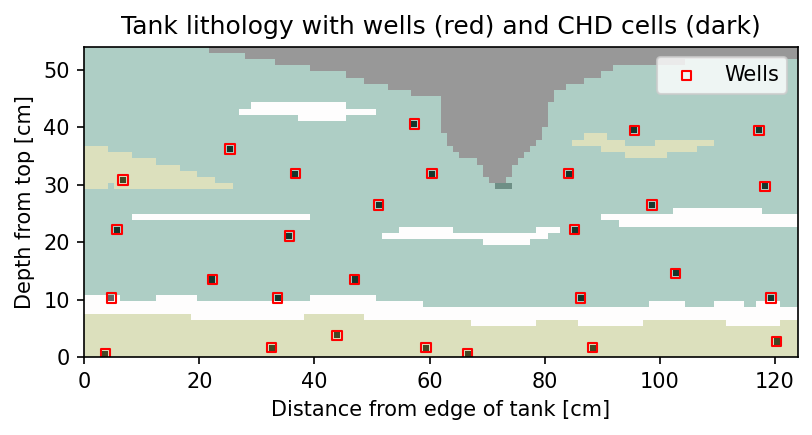

In [9]:
# Find the (row, col) of every well-flagged cell. np.where returns
# them in row-major order (top-to-bottom, then left-to-right).
well_rows, well_cols = np.where(heads_wells == 2)
print("Number of wells in the apparatus:", len(well_rows))

# Build coordinate arrays for plotting (cell edges)
x_edges = np.arange(ncol + 1) * delc
y_edges = np.linspace(0, tank_height, nlay + 1)

# Cell-center coordinates of each well (for scatter overlay)
well_x = (well_cols + 0.5) * delc
well_y = (well_rows + 0.5) * delv

# Plot lithology with the wells and CHD cells overlaid
fig, ax = plt.subplots(figsize=(9, 3), dpi=150)
ax.pcolormesh(x_edges, y_edges, hydrostrat, cmap='gist_earth')
ax.pcolormesh(x_edges, y_edges, heads_wells, cmap='Greys', alpha=0.6)
ax.scatter(well_x, well_y, s=20, marker='s',
           facecolors='none', edgecolors='red', linewidths=1, label='Wells')
              
ax.set_aspect('equal')
ax.set_xlabel('Distance from edge of tank [cm]')
ax.set_ylabel('Depth from top [cm]')
ax.set_title('Tank lithology with wells (red) and CHD cells (dark)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


## Hydraulic conductivity field

Map the lithology codes to `K` values using laboratory-measured
conductivities for each material. The remaining "out of bounds"
cells (lithology `0`) get `K = 0` here, but we will deactivate them
properly in the boundary-condition step below.


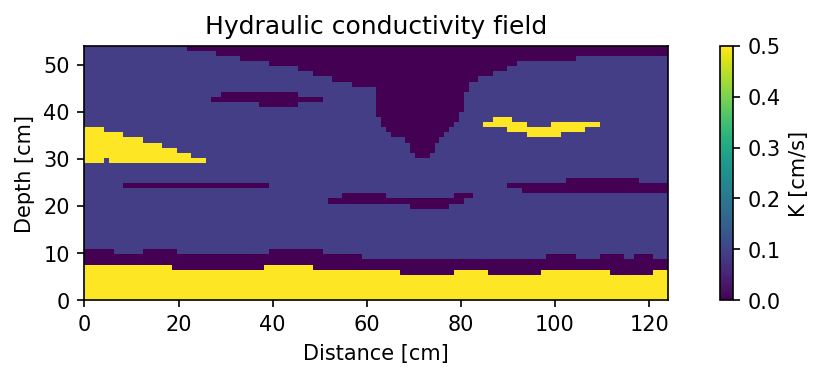

In [10]:
# Material-specific hydraulic conductivities (cm/s)
ksand   = 0.09
kgravel = 0.5
kclay   = 0.0001

# Build a 3D array of K values, one per cell
Hk = np.zeros((nlay, nrow, ncol))
hydrostrat_3d = hydrostrat.reshape((nlay, nrow, ncol))
Hk[hydrostrat_3d == 1] = ksand
Hk[hydrostrat_3d == 2] = kgravel
Hk[hydrostrat_3d == 3] = kclay
# hydrostrat == 0 cells stay at 0 (we'll deactivate them via ibound below)

# Plot it
plot_2d(np.squeeze(Hk), delc, delv, colorbar_label='K [cm/s]', cmap='viridis',
        title='Hydraulic conductivity field')


## Boundary conditions

Three things to set up:

1. **Out-of-bounds cells** — lithology `0` cells aren't part of the
   active model domain. Set `ibound = 0` for these to deactivate them
   (they are removed from the solver matrix).

2. **Constant-head boundaries** — the left edge of the tank is held at
   54 cm (the upstream reservoir) and the right edge at 46.5 cm (the
   downstream reservoir). This drives left-to-right flow.

3. **River cells** — the three CHD-flagged cells from the data file
   (the segment marked with `1` in `heads_wells`) discharge at
   39.5 cm, partway across the top of the tank.

In MODFLOW's BAS6 package, `ibound < 0` marks a constant-head cell.
We don't apply CHD to *every* cell on the left and right faces — only
the rows that are physically saturated (the carved-out corners are
left active so they can fill in based on the surrounding flow).

> **Note:** if you change the geometry or lithology data, you may need
> to revisit these slice indices. They are tied to the specific tank
> apparatus this model was built for.


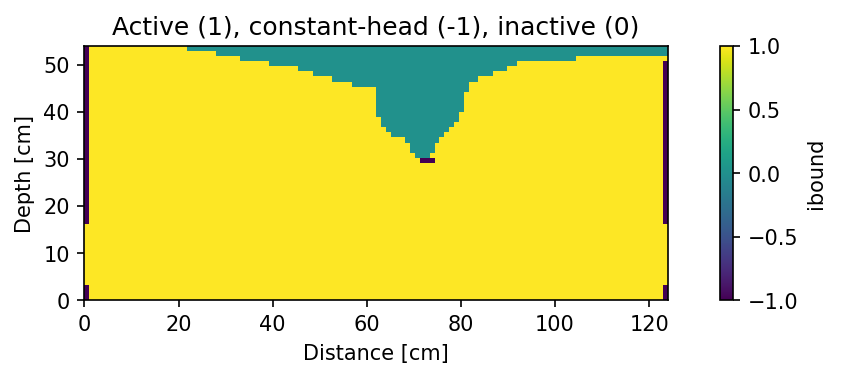

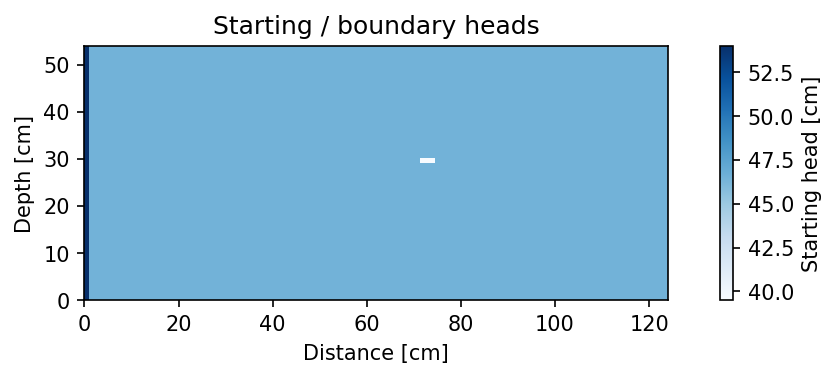

In [11]:
# Default: every cell is active (ibound = 1). MODFLOW will solve for
# the head in each active cell.
ibound = np.ones((nlay, nrow, ncol), dtype=int)

# Deactivate the out-of-bounds cells (lithology == 0)
ibound[hydrostrat_3d == 0] = 0

# Constant-head boundaries on the left and right faces.
# The slice ranges (3:15 etc.) skip the carved-out corners — those
# cells are left active so they participate in the flow solution.
ibound[15:-3, :, -1] = -1            # right face, mid-to-bottom rows
ibound[15:,   :,  0] = -1            # left face, mid-to-bottom rows
ibound[:3,    :, -1] = -1            # right face, top 3 rows
ibound[:3,    :,  0] = -1            # left face, top 3 rows

# Initialize starting heads. Active cells will get re-computed by
# MODFLOW; constant-head cells keep their assigned values.
strt = 46.5 * np.ones((nlay, nrow, ncol), dtype=float)
strt[:, :, 0]  = 54.0                # upstream reservoir at left
strt[:, :, -1] = 46.5                # downstream reservoir at right

# Add the "river" CHD cells (the segment marked with 1 in the data file)
chd_rows, chd_cols = np.where(heads_wells == 1)
for r, c in zip(chd_rows, chd_cols):
    ibound[r, 0, c] = -1
    strt[r,   0, c] = 39.5

# Plot the boundary configuration
plot_2d(np.squeeze(ibound), delc, delv,
        colorbar_label='ibound', cmap='viridis',
        title='Active (1), constant-head (-1), inactive (0)')
plot_2d(np.squeeze(strt), delc, delv,
        colorbar_label='Starting head [cm]', cmap='Blues',
        title='Starting / boundary heads')


## Wells: name → grid coordinate lookup

The tank has 28 observation wells. The data file marks their cell
locations with the value `2` but doesn't give them names. Below we
list the well names in **left-to-right order** (matching the physical
labels on the apparatus) and zip them with the cell coordinates that
`np.where` returns.

This gives us a dictionary that maps a well name (e.g. `"1D"`) to its
`(layer, col)` grid coordinate — useful for choosing where to inject
a tracer or where to record a breakthrough curve.


In [12]:
# Well names listed in left-to-right order, matching the physical
# labels on the tank apparatus.
well_names = [
    '1A', '1B', '1C', '1D', 'W1', 'W2', '2A', '2B', '2C', '2D',
    'W3', 'W4', 'W5', '3A', '3B', '3C', 'W6', '4A', '4B', '4C',
    '4D', 'W7', 'W8', 'W9', '5A', '5B', '5C', '5D',
]
assert len(well_names) == len(well_rows), \
    "Number of well names must match number of well cells in the data"

# Pair names with cells by sorting the (row, col) pairs left-to-right
# (by col), then zipping with well_names. Python's sort is stable, so
# wells in the same column are paired in row order (top-down).
sorted_rc = sorted(zip(well_rows, well_cols), key=lambda rc: rc[1])
well_coords = {name: (lay, col)
               for name, (lay, col) in zip(well_names, sorted_rc)}

# Show a few examples
for name in ['1A', '1D', 'W5', '5D']:
    lay, col = well_coords[name]
    print("Well %3s -> layer %2d, column %3d  (x = %.1f cm, depth = %.1f cm)"
          % (name, lay, col, (col + 0.5) * delc, (lay + 0.5) * delv))


Well  1A -> layer  0, column   3  (x = 3.6 cm, depth = 0.5 cm)
Well  1D -> layer 28, column   6  (x = 6.7 cm, depth = 30.8 cm)
Well  W5 -> layer 24, column  49  (x = 51.2 cm, depth = 26.5 cm)
Well  5D -> layer  2, column 116  (x = 120.4 cm, depth = 2.7 cm)


Pick the injection well by name. The cell below uses well `"1D"`, but
you can change this to any of the 28 well names.


In [13]:
# Pick which well to inject at
inj_well = '1D'
inj_lay, inj_col = well_coords[inj_well]
print("Injecting at well '%s' -> layer %d, column %d"
      % (inj_well, inj_lay, inj_col))


Injecting at well '1D' -> layer 28, column 6


## The model function

The function `tank_2D_model` wraps the entire MODFLOW-2005 + MT3D-USGS
build, run, and output extraction. The function signature is:

```
tank_2D_model(dirname, perlen, Hk, ibound, strt,
              Por, al, Q, Cinj, inj_lay, inj_col)
```

| Argument | Description |
|---|---|
| `dirname` | Sub-folder name for this run's input/output files. |
| `perlen` | List of stress-period lengths in **seconds**. Use `[t_pulse, t_rest]` for a pulse injection followed by clean water. |
| `Hk` | 3D hydraulic conductivity array (cm/s). |
| `ibound` | 3D boundary-condition flag array (`-1`/`0`/`1`). |
| `strt` | 3D starting-head array (cm). |
| `Por` | Effective porosity (-). |
| `al` | Longitudinal dispersivity (cm). |
| `Q` | Volumetric injection rate at the well (cm³/s, positive = injection). |
| `Cinj` | Concentration of injected water during stress period 0 (mg/cm³). |
| `inj_lay`, `inj_col` | Grid indices of the injection well. |

The function returns `heads` (steady-state head field), `times`
(saved transport output times in seconds), and `conc` (4D concentration
array, shape `(ntimes, nlay, nrow, ncol)`).

> **A note on units.** This notebook uses **seconds** throughout
> (`itmuni = 1`). The pulse duration is 50 s and the lab pump rate is
> ~0.18 cm³/s, so seconds are the natural choice for this experiment.
> The earlier 1D and 2D notebooks used minutes — the units don't
> matter as long as they're internally consistent.


In [16]:
def tank_2D_model(dirname, perlen, Hk, ibound, strt, Por, al, Q, Cinj, inj_lay, inj_col):
    """
    Build, run, and extract output from the 2D tank model.

    Returns
    -------
    heads : ndarray, shape (nlay, nrow, ncol)
        Steady-state head field. Inactive cells contain hnoflo
        (default 1e30 in MF2005 — mask before plotting).
    times : ndarray, shape (ntimes,)
        Output times (seconds).
    conc : ndarray, shape (ntimes, nlay, nrow, ncol)
        Concentration at every output time and grid cell.
    """
    tic = time.perf_counter()

    # ----- Workspace -----
    model_ws = os.path.join(workdir, dirname)
    print("Model workspace:", model_ws)

    # ----- Units (this notebook uses seconds + centimeters) -----
    itmuni = 1                # 1 = seconds  (MODFLOW)
    mt_tunit = 'S'            # MT3D string for the same unit
    lenuni = 3                # 3 = centimeters  (MODFLOW)
    mt_lunit = 'CM'

    # ----- Stress periods -----
    # Underlying flow is steady-state, so MODFLOW only needs ONE stress
    # period covering the full transport duration. MT3D, on the other
    # hand, gets multiple periods so we can switch the inlet
    # concentration off at the end of the pulse.
    perlen_mf = [np.sum(perlen)]
    nper_mf = len(perlen_mf)
    nper_mt = len(perlen)

    # ----- Output frequency -----
    nprs = 30                                  # number of saved snapshots
    timprs = np.linspace(0, np.sum(perlen), nprs, endpoint=False)

    # ----- Grid -----
    nlay_, nrow_, ncol_ = Hk.shape
    botm = -np.linspace(delv, delv * nlay_, nlay_)

    # ----- Injection well stress-period data -----
    # Constant flow rate Q in both periods. MT3D's SSM with itype=2
    # (well source) carries the concentration, which we drop to 0
    # when the pulse ends.
    spd_mf = {
        0: [[inj_lay, 0, inj_col, Q]],
        1: [[inj_lay, 0, inj_col, Q]],
    }
    itype = 2  # 2 = well source in MT3D
    spd_mt = {
        0: [[inj_lay, 0, inj_col, Cinj, itype]],
        1: [[inj_lay, 0, inj_col, 0.0,  itype]],
    }

    # ----- Solute transport icbund / initial concentration -----
    icbund = np.ones((nlay_, nrow_, ncol_), dtype=int)
    sconc  = np.zeros((nlay_, nrow_, ncol_), dtype=float)

    # ----- MODFLOW-2005 setup -----
    modelname_mf = dirname + '_mf'
    mf = flopy.modflow.Modflow(modelname=modelname_mf,
                               model_ws=model_ws,
                               exe_name=exe_name_mf)
    flopy.modflow.ModflowDis(mf, nlay=nlay_, nrow=nrow_, ncol=ncol_,
                             nper=nper_mf,
                             delr=delr, delc=delc, top=0.0, botm=botm,
                             perlen=perlen_mf,
                             itmuni=itmuni, lenuni=lenuni)
    flopy.modflow.ModflowBas(mf, ibound=ibound, strt=strt)
    flopy.modflow.ModflowLpf(mf, hk=Hk, vka=Hk, laytyp=0)
    flopy.modflow.ModflowWel(mf, stress_period_data=spd_mf)
    flopy.modflow.ModflowPcg(mf)
    flopy.modflow.ModflowLmt(mf)               # link to MT3D

    # OC must be present for MODFLOW to write the .hds file
    oc_spd = {(0, i): ['save head'] for i in range(nper_mf)}
    flopy.modflow.ModflowOc(mf, stress_period_data=oc_spd)

    mf.write_input()
    success_mf, _ = mf.run_model(silent=True)
    if not success_mf:
        raise RuntimeError("MODFLOW run in %s failed" % model_ws)

    # ----- MT3D-USGS setup -----
    modelname_mt = dirname + '_mt'
    mt = flopy.mt3d.Mt3dms(modelname=modelname_mt, model_ws=model_ws,
                           exe_name=exe_name_mt, modflowmodel=mf)
    flopy.mt3d.Mt3dBtn(mt, icbund=icbund, prsity=Por, sconc=sconc,
                       tunit=mt_tunit, lunit=mt_lunit,
                       nper=nper_mt, perlen=perlen,
                       nprs=nprs, timprs=timprs)
    # mixelm = -1 = third-order TVD scheme (low numerical dispersion)
    flopy.mt3d.Mt3dAdv(mt, mixelm=-1)
    flopy.mt3d.Mt3dDsp(mt, al=al, trpv=0.05)
    flopy.mt3d.Mt3dSsm(mt, stress_period_data=spd_mt)
    flopy.mt3d.Mt3dGcg(mt)

    mt.write_input()

    # Remove any stale concentration file before running
    ucn_path = os.path.join(model_ws, 'MT3D001.UCN')
    if os.path.isfile(ucn_path):
        os.remove(ucn_path)
    success_mt, _ = mt.run_model(silent=True)

    # ----- Extract output -----
    hds_path = os.path.join(model_ws, modelname_mf + '.hds')
    hdobj = flopy.utils.HeadFile(hds_path)
    heads = hdobj.get_data()                   # (nlay, nrow, ncol)

    ucnobj = flopy.utils.UcnFile(ucn_path)
    times = np.array(ucnobj.get_times())
    conc = ucnobj.get_alldata()                # (ntimes, nlay, nrow, ncol)

    toc = time.perf_counter()
    print("Model %s ran in %.2f seconds" % (dirname, toc - tic))
    return heads, times, conc


## Run the model

Define the parameters and call the function. Feel free to edit any of
these values and re-run.


In [17]:
# Simulation parameters
dirname = 'tank_run1'
perlen  = [50, 30 * 60]                  # 50-s pulse, then 30-min flush (seconds)
Por     = 0.3                            # porosity (-)
al      = 0.1                            # longitudinal dispersivity (cm)
Q       = 0.176                          # injection rate (cm^3/s)
Cinj    = 0.1                            # pulse concentration (mg/cm^3)

# Run the model
heads, times, conc = tank_2D_model(
    dirname, perlen, Hk, ibound, strt,
    Por, al, Q, Cinj, inj_lay, inj_col)

print("Concentration array shape:", conc.shape, "(ntimes, nlay, nrow, ncol)")
print("Number of saved output times:", len(times))
print("First/last output time:", times[0], "/", times[-1], "seconds")


Model workspace: .\tank_models\tank_run1
Model tank_run1 ran in 3.85 seconds
Concentration array shape: (32, 50, 1, 120) (ntimes, nlay, nrow, ncol)
Number of saved output times: 32
First/last output time: 0.0 / 1850.0 seconds


## Plot the steady-state head field

Inactive cells (out-of-bounds) come back from MODFLOW with the
`hnoflo` placeholder value (a very large negative number by default).
We mask these out before plotting so they don't dominate the colorbar.


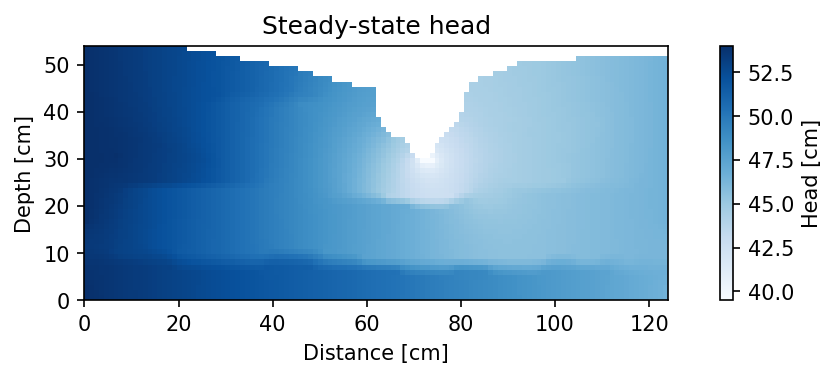

In [20]:
# Mask out inactive (out-of-bounds) cells before plotting. MODFLOW
# fills these with the hnoflo placeholder value (very large by default).
heads_plot = np.squeeze(heads).astype(float)
heads_plot[heads_plot < -100] = np.nan      # MF2005 default hnoflo is -1e30 or 1e30

plot_2d(heads_plot, delc, delv, colorbar_label='Head [cm]', cmap='Blues',
        title='Steady-state head')


## Plot the concentration field at a snapshot

Pick an output time (`time_step` is an integer index into the `times`
array). The cell below plots the concentration map roughly halfway
through the simulation.


Plotting concentration at t = 863.3 s (14.4 min)


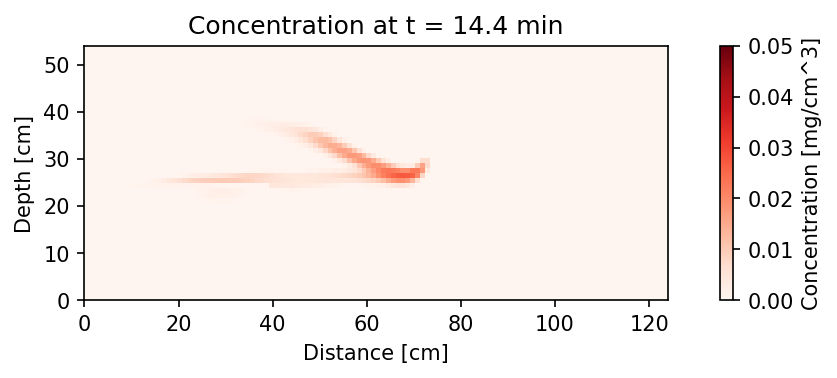

In [21]:
# Pick a snapshot index. Try a few different values to see how the
# plume evolves over time.
time_step = 15
print("Plotting concentration at t = %.1f s (%.1f min)"
      % (times[time_step], times[time_step] / 60))

plot_2d(np.squeeze(conc[time_step, :, :, :]), delc, delv,
        colorbar_label='Concentration [mg/cm^3]', cmap='Reds',
        clim=(0, 0.05),
        title='Concentration at t = %.1f min' % (times[time_step] / 60))


## Where to go from here

This is intentionally a bare-minimum model. Here are some directions
you can extend it in:

- **Add the sampling well.** In class we were sampling from a well pumping a specific rate. In order to compare measurements in lab, you will need to implement this well.

- **Calibrate the hydraulic conductivity.** Changing hydraulic conductivity will change the heads in some of the wells. Explore ways to match the modeled heads to the observations.

- **Vary the injection.** Change `inj_well` to a different name in the
  `well_coords` dictionary, or set `Q` and `Cinj` to different values.
  Try injecting at a well in the gravel zone vs. a well in the sand
  zone — how does the plume shape change?

- **Add reactive transport.** The MT3D-USGS Reactive Chemistry (RCT)
  package supports linear/Freundlich/Langmuir sorption and first-order
  decay. To enable it, instantiate the package inside the function:
  ```python
  flopy.mt3d.Mt3dRct(mt, isothm=1, ireact=0,
                      rhob=bulk_density, sp1=Kd)
  ```
  Pass `bulk_density` and `Kd` as additional function arguments.
  Compare the breakthrough curve to the conservative case.

- **Sample at other observation wells.** The `well_coords` dictionary you
  built above can be used to extract concentration time series at any
  named well. Loop through it to produce a multi-well BTC dataset.

- **Pulse vs. continuous injection.** Set `perlen[1] = 0` (or just use
  one stress period) and inject at concentration `Cinj` for the full
  duration. The breakthrough curves will look quite different.

